## <span style="color:green">Solutions</span>

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
ds = xr.open_dataset('/Users/Kroes027/Documents/PhD/Code/PythonCourse_IMAU_2024/PythonCourse_IMAU/data/gistemp1200_GHCNv4_ERSSTv5.nc')
example = ds.sel({'lat':0, 'lon':0}, method='nearest').tempanomaly

In [3]:
# 1. Create a dataset with two (10x10x10) DataArrays `A` and `B` 
# with dimensions `lat`, `lon`, `time` and some sensible coordinates.
# Use the `pd.date_range` function to create time coordinates 
# (use the `pd.date_range?` to find out how to use it).
# Create a `source` attribute that mentions who created the Dataset.
# Save the dataset as `test2.nc`.

nlat, nlon, ntime = 10, 10, 10
lats = np.linspace(-90, 90, nlat)
lons = np.linspace(0, 360, nlon)
times = pd.date_range(start='2020-01-01', end='2020-09-28', periods=ntime)
data_A = np.random.rand(nlat, nlon, ntime)
data_B = np.random.rand(nlat, nlon, ntime)
ds_ = xr.Dataset(data_vars={'A':(('lat','lon','time'), data_A),
                           'B':(('lat','lon','time'), data_B),
                          },
                coords={'lat':lats, 'lon':lons, 'time':times}
               )
ds_.attrs['source'] = 'created by André Jüling'
print(ds_)
ds_.to_netcdf('test2.nc')

<xarray.Dataset>
Dimensions:  (lat: 10, lon: 10, time: 10)
Coordinates:
  * lat      (lat) float64 -90.0 -70.0 -50.0 -30.0 -10.0 ... 30.0 50.0 70.0 90.0
  * lon      (lon) float64 0.0 40.0 80.0 120.0 160.0 ... 240.0 280.0 320.0 360.0
  * time     (time) datetime64[ns] 2020-01-01 2020-01-31T02:40:00 ... 2020-09-28
Data variables:
    A        (lat, lon, time) float64 0.02669 0.0935 0.1509 ... 0.5771 0.4958
    B        (lat, lon, time) float64 0.3202 0.9257 0.01563 ... 0.4259 0.3142
Attributes:
    source:   created by André Jüling


<xarray.DataArray 'tempanomaly' ()>
array(0.3930833, dtype=float32)
Coordinates:
    lat      float32 51.0
    lon      float32 3.0


FileNotFoundError: [Errno 2] No such file or directory: 'figures/3b2.png'

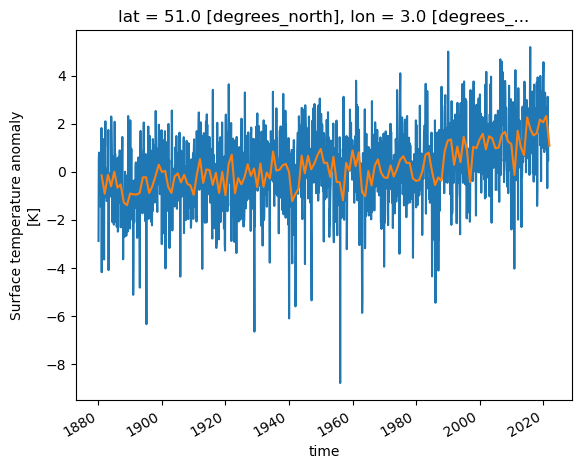

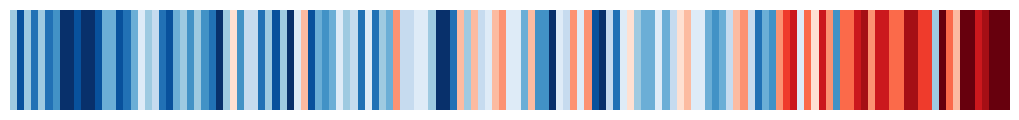

In [4]:
# 2. Select the time series of temperature anomalies of you birth place 
# from the GISSTEMP dataset `ds` that we briefly inspected before.
# Use the `resample(time='A').mean()` to create annual means.
# Calculate the temperature mean between 1970 and 2000 and use it as a reference.
# Create the iconic warming stripes graphic.
# Use this tutorial as an inspiration: https://matplotlib.org/matplotblog/posts/warming-stripes/
timeseries = ds.tempanomaly.sel({'lat':51.4485683, 'lon':3.5703873}, method='nearest')
reference = timeseries.sel({'time':slice('1970-01-01','2000-01-01')}).mean()
print(reference)
annual = timeseries.resample(time='A').mean()
timeseries.plot()
annual.plot()

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    '#08306b', '#08519c', '#2171b5', '#4292c6',
    '#6baed6', '#9ecae1', '#c6dbef', '#deebf7',
    '#fee0d2', '#fcbba1', '#fc9272', '#fb6a4a',
    '#ef3b2c', '#cb181d', '#a50f15', '#67000d',
])

fig = plt.figure(figsize=(10, 1))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()
col = PatchCollection([Rectangle((y, 0), 1, 1) for y in range(1880, 2020 + 1)])
col.set_array(annual.values)
col.set_cmap(cmap)
col.set_clim(reference-1.5, reference+1.5)
ax.add_collection(col)
ax.set_ylim(0, 1)
ax.set_xlim(1880,2020+1)
plt.savefig('figures/3b2')

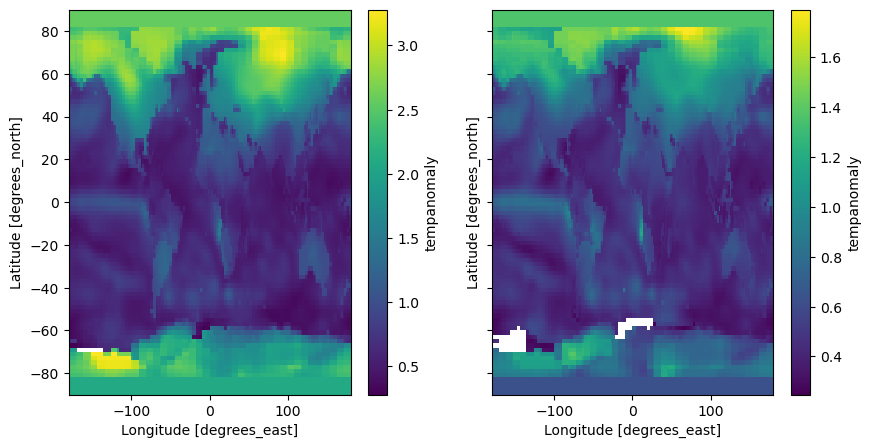

In [5]:
# 3. Calculate the standard deviation of the monthly and annual temperatures 
# and create two maps thereof in a single figure.
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True)
ds.tempanomaly.std('time').plot(ax=ax[0])
ds.tempanomaly.rolling(time=12, center=True).mean().std('time').plot(ax=ax[1])

In [6]:
# 4. Calculate the linear trend of a temperature time series above in [$^\circ$C/century].
pf = np.polyfit(example.time.dt.year+example.time.dt.month/12, example, deg=1)
print(f'The temperature increase is {pf[0]*100:.1f} K/century')

The temperature increase is 1.0 K/century
